Используется набор `sklearn.datasets.load_diabetes`. В выборке 442 наблюдения и 10 объясняющих факторов. Зависимая переменная - `target`, показатель прогрессирования болезни через год. Для PCA, иерархической кластеризации и K-means она не используется, иначе разбиение и компоненты будут частично построены по тому, что потом надо объяснять.

Четыре наблюдения заранее откладываю как новые объекты для дискриминантного анализа. Основной расчет идет по остальным 438 наблюдениям.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import f_oneway
from sklearn.cluster import KMeans
from sklearn.datasets import load_diabetes
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import accuracy_score, calinski_harabasz_score, confusion_matrix, davies_bouldin_score, mean_squared_error, r2_score, silhouette_score
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.unicode_minus"] = False

In [2]:
diabetes = load_diabetes(as_frame=True)
X_all = diabetes.data.copy()
y_all = diabetes.target.rename("target")

check = pd.DataFrame({
    "n": [len(X_all)],
    "factors": [X_all.shape[1]],
    "target_in_factors": ["target" in X_all.columns],
})

desc = pd.concat([X_all, y_all], axis=1).describe().T[["mean", "std", "min", "50%", "max"]]
display(check)
display(desc.round(3))

,n,factors,target_in_factors
0,442,10,False


,mean,std,min,50%,max
age,-0.000,0.048,-0.107,0.005,0.111
sex,0.000,0.048,-0.045,-0.045,0.051
bmi,-0.000,0.048,-0.090,-0.007,0.171
bp,-0.000,0.048,-0.112,-0.006,0.132
s1,-0.000,0.048,-0.127,-0.004,0.154
s2,0.000,0.048,-0.116,-0.004,0.199
s3,-0.000,0.048,-0.102,-0.007,0.181
s4,-0.000,0.048,-0.076,-0.003,0.185
s5,0.000,0.048,-0.126,-0.002,0.134
s6,0.000,0.048,-0.138,-0.001,0.136


Все признаки в наборе уже отмасштабированы авторами данных, но для PCA и кластеризации все равно используется стандартизация. Это убирает случайный перекос из-за масштаба и делает нагрузки и расстояния сравнимыми. `target` остается отдельно.

In [3]:
rng = np.random.default_rng(2026)
new_ids = np.sort(rng.choice(X_all.index.to_numpy(), size=4, replace=False))
train_ids = X_all.index.difference(new_ids)

X = X_all.loc[train_ids].copy()
y = y_all.loc[train_ids].copy()
X_new = X_all.loc[new_ids].copy()
y_new = y_all.loc[new_ids].copy()

scaler = StandardScaler()
Xz = pd.DataFrame(scaler.fit_transform(X), index=X.index, columns=X.columns)
Xz_new = pd.DataFrame(scaler.transform(X_new), index=X_new.index, columns=X_new.columns)

scale_check = Xz.agg(["mean", "std"]).T
display(pd.DataFrame({"new_object_id": new_ids, "target": y_new.values}))
display(scale_check.round(3))

,new_object_id,target
0,11,69.0
1,78,252.0
2,282,230.0
3,373,168.0


,mean,std
age,-0.0,1.001
sex,-0.0,1.001
bmi,-0.0,1.001
bp,0.0,1.001
s1,-0.0,1.001
s2,0.0,1.001
s3,0.0,1.001
s4,0.0,1.001
s5,-0.0,1.001
s6,-0.0,1.001


Средние после стандартизации практически нулевые, стандартные отклонения близки к 1. Значит, PCA и кластеры дальше считаются по одной шкале. Новые объекты не участвуют в подборе кластеров, они нужны только для последней проверки.

,component,eigenvalue,share_pct,cum_pct
0,PC1,4.053,40.440,40.440
1,PC2,1.494,14.910,55.349
2,PC3,1.209,12.063,67.412
3,PC4,0.956,9.543,76.955
4,PC5,0.660,6.588,83.542
5,PC6,0.601,5.999,89.542
6,PC7,0.527,5.257,94.799
7,PC8,0.434,4.333,99.132
8,PC9,0.078,0.782,99.914
9,PC10,0.009,0.086,100.000


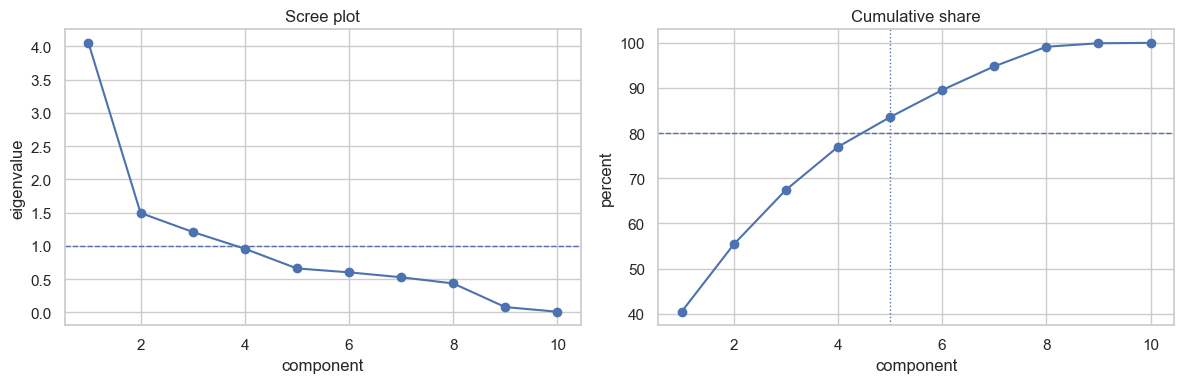

In [4]:
pca = PCA()
pc = pca.fit_transform(Xz)
pc_names = [f"PC{i}" for i in range(1, Xz.shape[1] + 1)]

pca_table = pd.DataFrame({
    "component": pc_names,
    "eigenvalue": pca.explained_variance_,
    "share": pca.explained_variance_ratio_,
    "cum_share": np.cumsum(pca.explained_variance_ratio_),
})
pca_table["share_pct"] = pca_table["share"] * 100
pca_table["cum_pct"] = pca_table["cum_share"] * 100

display(pca_table[["component", "eigenvalue", "share_pct", "cum_pct"]].round(3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(range(1, 11), pca.explained_variance_, marker="o")
ax[0].axhline(1, linestyle="--", linewidth=1)
ax[0].set_title("Scree plot")
ax[0].set_xlabel("component")
ax[0].set_ylabel("eigenvalue")
ax[1].plot(range(1, 11), pca_table["cum_pct"], marker="o")
ax[1].axhline(80, linestyle="--", linewidth=1)
ax[1].axvline(5, linestyle=":", linewidth=1)
ax[1].set_title("Cumulative share")
ax[1].set_xlabel("component")
ax[1].set_ylabel("percent")
plt.tight_layout()
plt.show()

По критерию Кайзера проходят 3 компоненты, потому что только у них собственные значения больше 1. Их накопленный вклад - около 67 процентов. Для отчета этого мало: остается почти треть исходной вариации. Порог 80 процентов достигается на 5 компонентах, поэтому оставлены 5. Scree plot показывает сильный спад после первой компоненты и более ровный участок после третьей, но четвертая и пятая компоненты все еще дают нормальный прирост.

,PC1,PC2,PC3,PC4,PC5
age,0.430,0.033,0.568,0.385,0.542
sex,0.376,-0.474,-0.119,0.668,-0.291
bmi,0.609,-0.192,0.174,-0.503,-0.121
bp,0.546,-0.178,0.557,0.012,-0.428
s1,0.687,0.704,-0.059,0.075,-0.102
s2,0.705,0.565,-0.279,0.170,-0.094
s3,-0.574,0.605,0.434,0.073,-0.191
s4,0.864,-0.071,-0.415,-0.002,0.116
s5,0.769,-0.026,0.058,-0.247,0.120
s6,0.649,-0.118,0.293,-0.084,0.028


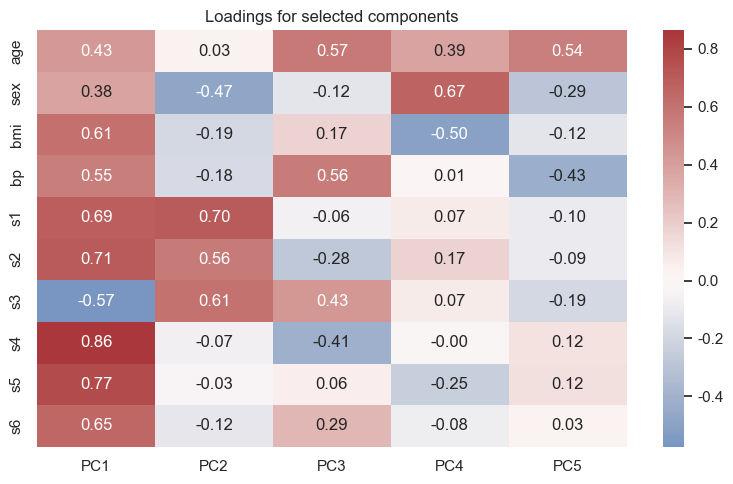

In [5]:
loadings = pd.DataFrame(
    pca.components_.T * np.sqrt(pca.explained_variance_),
    index=Xz.columns,
    columns=pc_names,
)

display(loadings.iloc[:, :5].round(3))
plt.figure(figsize=(8, 5))
sns.heatmap(loadings.iloc[:, :5], annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Loadings for selected components")
plt.tight_layout()
plt.show()

PC1 выглядит как общий метаболический профиль: положительно связана с `s4`, `s5`, `s2`, `s1`, `bmi`, `bp`, `s6`, а `s3` идет в обратную сторону. PC2 больше про липидную структуру, потому что самые заметные нагрузки у `s1`, `s2`, `s3` и `sex`. PC3 собирает возраст, давление, `s3` и `s6`. PC4 отделяет `sex` от `bmi`, а PC5 в основном держится на `age`.

Главная мысль такая: первая компонента показывает общий уровень обменной нагрузки, а остальные помогают не смешивать разные стороны этого профиля в одну ось.

In [6]:
pc_count = 5
pc_frame = pd.DataFrame(pc[:, :pc_count], index=X.index, columns=pc_names[:pc_count])
pc_model = sm.OLS(y, sm.add_constant(pc_frame)).fit()

pc_coef = pd.DataFrame({
    "coef": pc_model.params,
    "std_err": pc_model.bse,
    "p_value": pc_model.pvalues,
})

display(pc_coef.round(4))
print(round(pc_model.rsquared, 3), round(pc_model.rsquared_adj, 3))

,coef,std_err,p_value
const,151.8813,2.6091,0.0000
PC1,21.4829,1.2975,0.0000
PC2,-12.2929,2.1368,0.0000
PC3,10.5209,2.3756,0.0000
PC4,-28.2952,2.6710,0.0000
PC5,-1.1848,3.2147,0.7126


0.504 0.498


Уравнение регрессии на главных компонентах:

$$\widehat{target}=151.88+21.48PC_1-12.29PC_2+10.52PC_3-28.30PC_4-1.18PC_5$$

Первые четыре компоненты значимы, а PC5 почти ничего не добавляет к объяснению `target`. PC5 не исключается из PCA, потому что выбор числа компонент делался по суммарной вариации. Но для самой регрессии видно, что полезная часть в основном сидит в PC1-PC4.

,model,train_R2,CV_R2,CV_RMSE
0,linear,0.520,0.477,54.549
1,pca_5,0.504,0.471,54.957
2,poly_2_ridge,0.576,0.468,55.118


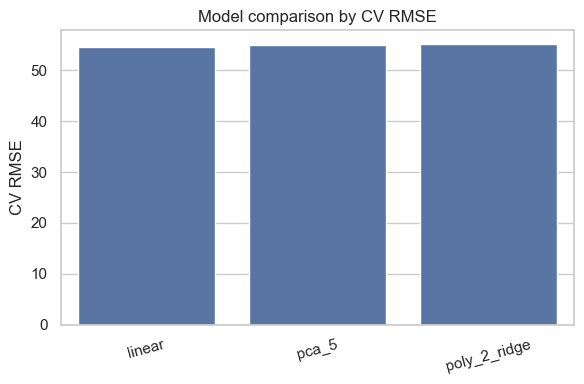

In [7]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)
models = {
    "linear": Pipeline([("scale", StandardScaler()), ("model", LinearRegression())]),
    "pca_5": Pipeline([("scale", StandardScaler()), ("pca", PCA(n_components=5)), ("model", LinearRegression())]),
    "poly_2_ridge": Pipeline([
        ("scale", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("model", RidgeCV(alphas=np.logspace(-3, 3, 25), cv=5)),
    ]),
}

rows = []
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring={"r2": "r2", "rmse": "neg_root_mean_squared_error"})
    model.fit(X, y)
    fitted = model.predict(X)
    rows.append({
        "model": name,
        "train_R2": r2_score(y, fitted),
        "CV_R2": scores["test_r2"].mean(),
        "CV_RMSE": -scores["test_rmse"].mean(),
    })

model_compare = pd.DataFrame(rows).sort_values("CV_RMSE")
display(model_compare.round(3))

plt.figure(figsize=(6, 4))
sns.barplot(data=model_compare, x="model", y="CV_RMSE")
plt.title("Model comparison by CV RMSE")
plt.xlabel("")
plt.ylabel("CV RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

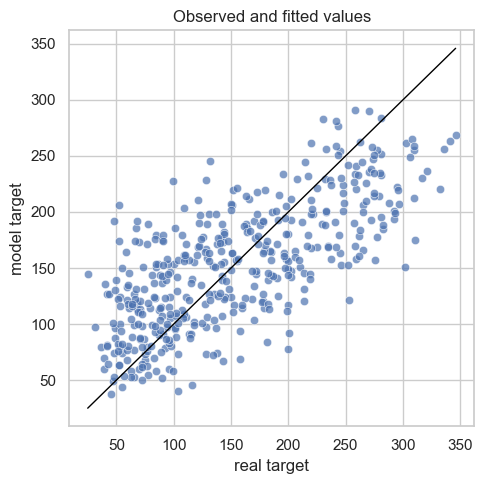

In [8]:
best_model = models["linear"]
best_model.fit(X, y)
y_hat = best_model.predict(X)

plt.figure(figsize=(5, 5))
sns.scatterplot(x=y, y=y_hat, alpha=0.7)
mn = min(y.min(), y_hat.min())
mx = max(y.max(), y_hat.max())
plt.plot([mn, mx], [mn, mx], color="black", linewidth=1)
plt.xlabel("real target")
plt.ylabel("model target")
plt.title("Observed and fitted values")
plt.tight_layout()
plt.show()

Сравнение с линейной и нелинейной моделью сделано так же, как в первой работе: учитывается не только R2 на всей выборке, но и качество на кросс-валидации. Линейная модель на исходных факторах получилась немного лучше по CV RMSE. Регрессия на 5 ГК почти рядом, но она хуже интерпретируется в терминах исходных показателей. Квадратичная Ridge-модель лучше подгоняет обучающую выборку, но на проверке не выигрывает, поэтому она не выбирается.

,method,last_height,prev_height
0,single,3.232,2.839
1,complete,11.189,9.380
2,average,5.335,5.236
3,centroid,7.019,4.822
4,ward,42.232,29.860
5,median,7.564,4.848


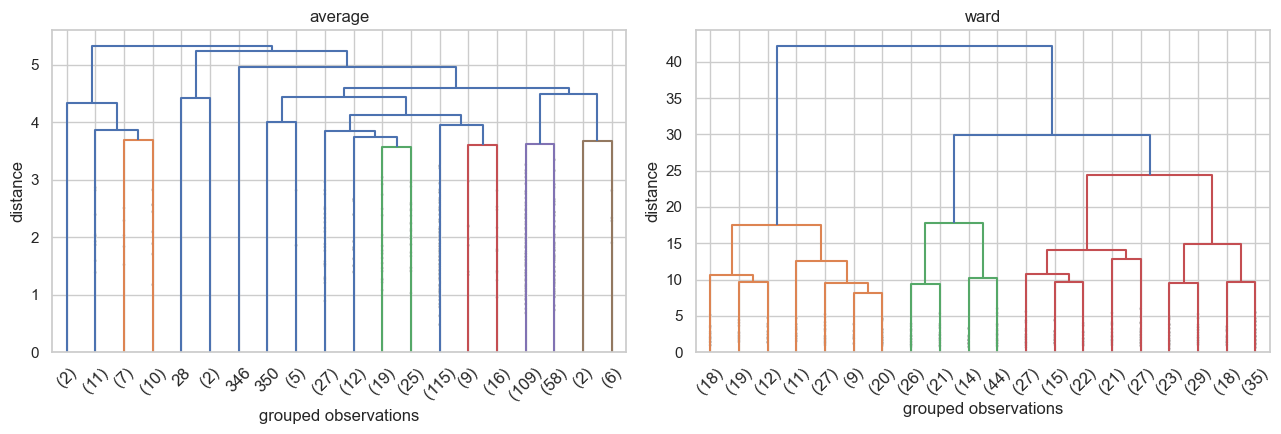

In [9]:
methods = ["single", "complete", "average", "centroid", "ward", "median"]
link_rows = []
for m in methods:
    z = linkage(Xz, method=m)
    link_rows.append({"method": m, "last_height": z[-1, 2], "prev_height": z[-2, 2]})

link_table = pd.DataFrame(link_rows)
display(link_table.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, m in zip(axes, ["average", "ward"]):
    z = linkage(Xz, method=m)
    dendrogram(z, truncate_mode="lastp", p=20, show_contracted=True, leaf_rotation=45, ax=ax)
    ax.set_title(m)
    ax.set_xlabel("grouped observations")
    ax.set_ylabel("distance")
plt.tight_layout()
plt.show()

Посчитаны 6 вариантов иерархической кластеризации, но в выводе оставлены только average и Ward. Их дендрограммы читаются нормально. Single linkage дает цепочку, а centroid и median выглядят менее устойчиво. На двух выбранных дендрограммах заметнее всего крупное деление на две части.

,k,sizes,silhouette,calinski,davies
0,2,"211, 227",0.238,171.637,1.541
1,3,"158, 156, 124",0.154,117.185,1.974
2,4,"107, 88, 144, 99",0.142,98.092,1.905
3,5,"81, 89, 85, 74, 109",0.148,87.362,1.897
4,6,"93, 81, 72, 54, 73, 65",0.145,79.804,1.799


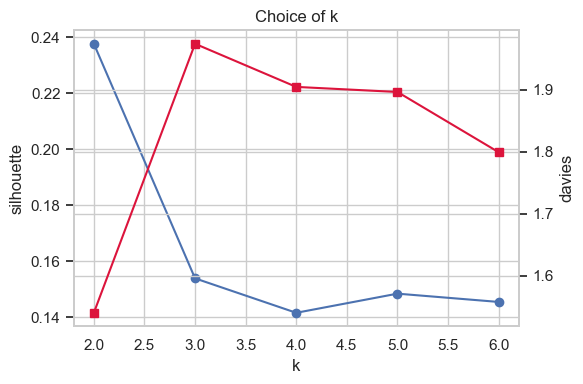

In [10]:
km_rows = []
labels_by_k = {}
for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42, n_init=50)
    lbl = model.fit_predict(Xz)
    labels_by_k[k] = lbl
    km_rows.append({
        "k": k,
        "sizes": ", ".join(map(str, np.bincount(lbl))),
        "silhouette": silhouette_score(Xz, lbl),
        "calinski": calinski_harabasz_score(Xz, lbl),
        "davies": davies_bouldin_score(Xz, lbl),
    })

km_quality = pd.DataFrame(km_rows)
display(km_quality.round(3))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(km_quality["k"], km_quality["silhouette"], marker="o", label="silhouette")
ax2 = ax.twinx()
ax2.plot(km_quality["k"], km_quality["davies"], marker="s", color="crimson", label="davies")
ax.set_xlabel("k")
ax.set_ylabel("silhouette")
ax2.set_ylabel("davies")
plt.title("Choice of k")
plt.tight_layout()
plt.show()

По метрикам лучшее число кластеров - 2. У этого варианта максимальный Silhouette и самый низкий Davies-Bouldin. Три и более кластеров дают больше деталей, но качество падает. Поэтому выбраны 2 группы, без усложнения разбиения только ради более красивого описания.

,n,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
cluster,,,,,,,,,,,,
1,211,-0.370,-0.335,-0.536,-0.467,-0.539,-0.573,0.562,-0.750,-0.694,-0.553,112.706
2,227,0.344,0.311,0.498,0.434,0.501,0.533,-0.523,0.697,0.645,0.514,188.295


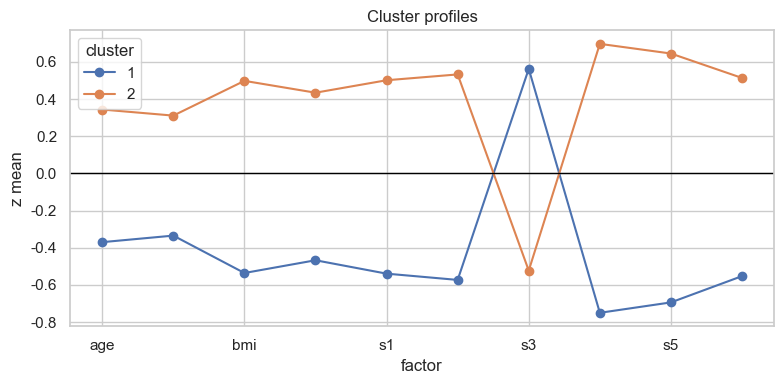

In [11]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=50)
raw = kmeans.fit_predict(Xz)
means_tmp = pd.Series(y.values).groupby(raw).mean().sort_values()
map_tmp = {old: i + 1 for i, old in enumerate(means_tmp.index)}
cluster = pd.Series([map_tmp[i] for i in raw], index=X.index, name="cluster")
cluster_name = cluster.map({1: "moderate profile", 2: "metabolic risk"})

profile = Xz.copy()
profile["target"] = y.values
profile["cluster"] = cluster.values
profile_table = profile.groupby("cluster").mean()
profile_table.insert(0, "n", profile.groupby("cluster").size())
display(profile_table.round(3))

plot_profile = profile_table.drop(columns=["n", "target"]).T
plot_profile.plot(marker="o", figsize=(8, 4))
plt.axhline(0, color="black", linewidth=1)
plt.title("Cluster profiles")
plt.xlabel("factor")
plt.ylabel("z mean")
plt.tight_layout()
plt.show()

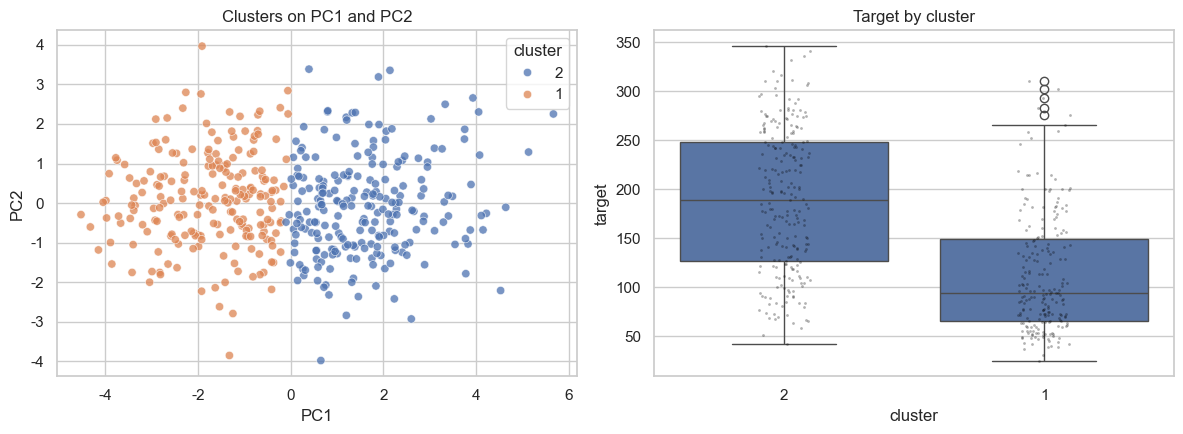

In [12]:
plot_df = pd.DataFrame({
    "PC1": pc_frame["PC1"],
    "PC2": pc_frame["PC2"],
    "cluster": cluster.astype(str),
    "target": y.values,
})

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="cluster", ax=ax[0], alpha=0.75)
ax[0].set_title("Clusters on PC1 and PC2")
sns.boxplot(data=plot_df, x="cluster", y="target", ax=ax[1])
sns.stripplot(data=plot_df, x="cluster", y="target", ax=ax[1], color="black", alpha=0.3, size=2)
ax[1].set_title("Target by cluster")
plt.tight_layout()
plt.show()

In [13]:
anova_rows = []
for col in list(Xz.columns) + ["target"]:
    g1 = profile.loc[profile["cluster"] == 1, col]
    g2 = profile.loc[profile["cluster"] == 2, col]
    f, p = f_oneway(g1, g2)
    anova_rows.append({"factor": col, "mean_1": g1.mean(), "mean_2": g2.mean(), "F": f, "p_value": p})

anova_table = pd.DataFrame(anova_rows)
display(anova_table.round(4))

,factor,mean_1,mean_2,F,p_value
0,age,-0.3698,0.3437,63.4873,0.0
1,sex,-0.3346,0.3110,50.6410,0.0
2,bmi,-0.5358,0.4980,158.6575,0.0
3,bp,-0.4672,0.4343,110.9749,0.0
4,s1,-0.5393,0.5013,161.5182,0.0
5,s2,-0.5730,0.5326,191.5044,0.0
6,s3,0.5625,-0.5228,181.6434,0.0
7,s4,-0.7499,0.6971,477.5250,0.0
8,s5,-0.6940,0.6450,353.3363,0.0
9,s6,-0.5526,0.5137,172.8113,0.0


Первый кластер назван умеренным профилем: у него ниже `bmi`, `bp`, `s1`, `s2`, `s4`, `s5`, `s6`, а `s3` выше среднего. Второй кластер - метаболический риск: почти все эти показатели идут выше среднего, а `s3` ниже. `target` не участвовал в кластеризации, но после разбиения средний `target` заметно выше во втором кластере. Это хороший знак: группы имеют не только статистическое, но и содержательное различие.

ANOVA показывает значимые различия по всем факторам. Самое сильное разделение идет по `s4`, `s5`, `s2`, `s3` и `s6`, то есть кластеры держатся на общем обменном профиле, а не на одном случайном признаке.

In [14]:
reg_rows = []
coef_rows = []
for c in [1, 2]:
    idx = cluster == c
    local_x = Xz.loc[idx]
    local_y = y.loc[idx]
    local_model = sm.OLS(local_y, sm.add_constant(local_x)).fit()
    pred = local_model.predict(sm.add_constant(local_x))
    reg_rows.append({
        "cluster": c,
        "n": int(idx.sum()),
        "R2": local_model.rsquared,
        "adj_R2": local_model.rsquared_adj,
        "RMSE": mean_squared_error(local_y, pred) ** 0.5,
    })
    for term, coef, p in zip(["const"] + list(Xz.columns), local_model.params, local_model.pvalues):
        coef_rows.append({"cluster": c, "term": term, "coef": coef, "p_value": p})

cluster_reg = pd.DataFrame(reg_rows)
cluster_coef = pd.DataFrame(coef_rows)
sig_coef = cluster_coef[(cluster_coef["term"] != "const") & (cluster_coef["p_value"] < 0.05)].copy()
sig_coef["abs_coef"] = sig_coef["coef"].abs()
sig_coef = sig_coef.sort_values(["cluster", "abs_coef"], ascending=[True, False]).drop(columns="abs_coef")

display(cluster_reg.round(3))
display(sig_coef.round(4))

,cluster,n,R2,adj_R2,RMSE
0,1,211,0.341,0.308,48.938
1,2,227,0.466,0.442,53.238


,cluster,term,coef,p_value
5,1,s1,241.6436,0.0016
6,1,s2,-215.1817,0.0012
7,1,s3,-105.5990,0.0005
2,1,sex,-13.5958,0.0013
4,1,bp,13.4166,0.0036
3,1,bmi,13.1482,0.0071
16,2,s1,-76.4578,0.0119
17,2,s2,57.3198,0.0206
20,2,s5,54.0368,0.0005
14,2,bmi,33.4027,0.0000


Регрессии внутри кластеров отличаются. В первом кластере сильнее заметны `s1`, `s2`, `s3`, `sex`, `bp`, `bmi`. Во втором кластере понятнее работают `bmi`, `bp` и `s5`; качество модели там выше. Это значит, что одна общая регрессия сглаживает различия между группами. Разные профили пациентов лучше описывать отдельно, хотя полностью проблему разброса это не решает.

In [15]:
lda = LinearDiscriminantAnalysis()
lda.fit(Xz, cluster)
lda_train = lda.predict(Xz)
cv2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lda_cv = cross_val_predict(LinearDiscriminantAnalysis(), Xz, cluster, cv=cv2)

train_matrix = pd.DataFrame(confusion_matrix(cluster, lda_train, labels=[1, 2]), index=["kmeans_1", "kmeans_2"], columns=["lda_1", "lda_2"])
cv_matrix = pd.DataFrame(confusion_matrix(cluster, lda_cv, labels=[1, 2]), index=["kmeans_1", "kmeans_2"], columns=["lda_1", "lda_2"])
lda_coef = pd.DataFrame({"factor": Xz.columns, "coef": lda.coef_[0], "scaling": lda.scalings_[:, 0]}).sort_values("coef", key=lambda s: s.abs(), ascending=False)

display(pd.DataFrame({"train_accuracy": [accuracy_score(cluster, lda_train)], "cv_accuracy": [accuracy_score(cluster, lda_cv)]}).round(3))
display(train_matrix)
display(cv_matrix)
display(lda_coef.round(3))

,train_accuracy,cv_accuracy
0,0.968,0.963


,lda_1,lda_2
kmeans_1,201,10
kmeans_2,4,223


,lda_1,lda_2
kmeans_1,200,11
kmeans_2,5,222


,factor,coef,scaling
5,s2,3.533,1.129
8,s5,2.727,0.871
4,s1,-2.009,-0.642
9,s6,0.796,0.255
2,bmi,0.743,0.237
3,bp,0.685,0.219
0,age,0.644,0.206
6,s3,-0.640,-0.205
1,sex,0.466,0.149
7,s4,0.440,0.141


Дискриминантная функция для двух кластеров:

$$D=0.252+0.644age+0.466sex+0.743bmi+0.685bp-2.009s_1+3.533s_2-0.640s_3+0.440s_4+2.727s_5+0.796s_6$$

Модель почти полностью повторяет K-means. На кросс-валидации точность остается около 96 процентов, значит кластеры нормально отделяются линейной границей. Самые крупные коэффициенты у `s2`, `s5`, `s1`, `s6`, `bmi` и `bp`, что совпадает с профилями кластеров.

,target,kmeans,lda,P_cluster_1,P_cluster_2
11,69.0,2,1,0.587,0.413
78,252.0,1,1,0.861,0.139
282,230.0,2,2,0.009,0.991
373,168.0,1,1,0.997,0.003


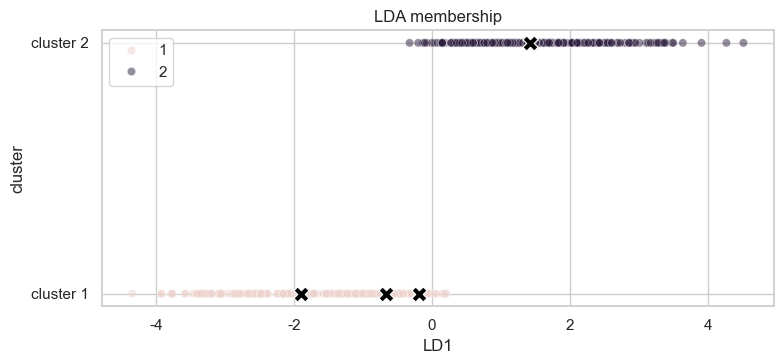

In [16]:
new_kmeans_raw = kmeans.predict(Xz_new)
new_kmeans = pd.Series([map_tmp[i] for i in new_kmeans_raw], index=X_new.index)
new_lda = pd.Series(lda.predict(Xz_new), index=X_new.index)
new_prob = pd.DataFrame(lda.predict_proba(Xz_new), index=X_new.index, columns=["P_cluster_1", "P_cluster_2"])

new_result = pd.DataFrame({
    "target": y_new,
    "kmeans": new_kmeans,
    "lda": new_lda,
}).join(new_prob)

display(new_result.round(3))

lda_train_coord = pd.DataFrame(lda.transform(Xz), index=X.index, columns=["LD1"])
lda_train_coord["cluster"] = cluster.values
lda_new_coord = pd.DataFrame(lda.transform(Xz_new), index=X_new.index, columns=["LD1"])
lda_new_coord["cluster"] = new_lda.values

plt.figure(figsize=(8, 3.8))
sns.scatterplot(data=lda_train_coord, x="LD1", y="cluster", hue="cluster", alpha=0.5)
sns.scatterplot(data=lda_new_coord, x="LD1", y="cluster", color="black", marker="X", s=120)
plt.yticks([1, 2], ["cluster 1", "cluster 2"])
plt.title("LDA membership")
plt.tight_layout()
plt.show()

Из четырех новых объектов три классифицируются уверенно. Объект 11 получился пограничным: K-means относит его ко второму кластеру, а дискриминантный анализ - к первому, причем вероятности близкие. Это не выглядит как провал разбиения, скорее объект находится около границы групп.

Вывод

Для PCA оставлены 5 компонент: они объясняют больше 80 процентов дисперсии и еще читаются по факторным нагрузкам. Лучшая регрессионная модель по проверке качества - линейная модель на исходных факторах; регрессия на ГК почти рядом, но хуже по предметной интерпретации. Кластеризация дала две группы: умеренный профиль и метаболический риск. Они различаются по исходным факторам и по `target`, хотя `target` в кластеризацию не входил. Дискриминантный анализ подтвердил это разбиение: почти все объекты возвращаются в те же группы, а спорные случаи находятся около границы.